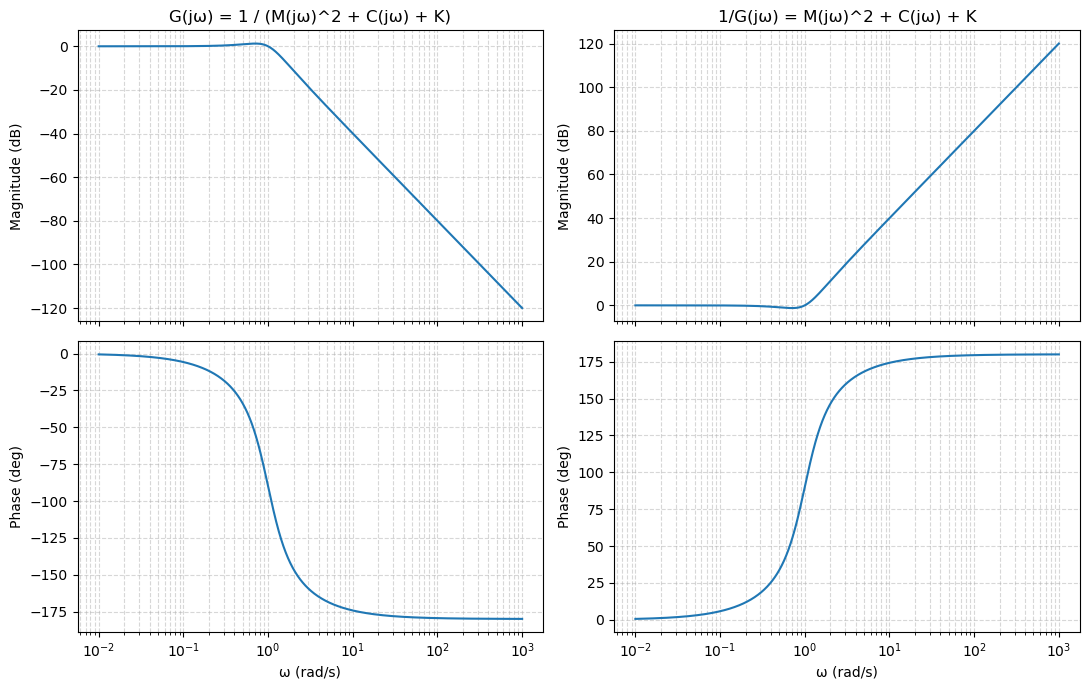

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- set your parameters (SI units) ----
M = 1.0   # kg
C = 1.0   # N*s/m
K = 1.0   # N/m

# ---- frequency grid (rad/s) ----
w = np.logspace(-2, 3, 2000)   # adjust as you like
s = 1j*w

# ---- frequency responses ----
G = 1.0 / (M*s**2 + C*s + K)
invG = 1.0 / G   # = M s^2 + C s + K

def bode_mag_phase(H):
    mag_db = 20*np.log10(np.abs(H))
    phase_deg = np.unwrap(np.angle(H)) * 180/np.pi
    return mag_db, phase_deg

G_mag, G_phase = bode_mag_phase(G)
iG_mag, iG_phase = bode_mag_phase(invG)

# ---- plot ----
fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharex='col')

# G(s)
ax[0,0].semilogx(w, G_mag)
ax[1,0].semilogx(w, G_phase)
ax[0,0].set_title("G(jω) = 1 / (M(jω)^2 + C(jω) + K)")
ax[0,0].set_ylabel("Magnitude (dB)")
ax[1,0].set_ylabel("Phase (deg)")
ax[1,0].set_xlabel("ω (rad/s)")

# 1/G(s)
ax[0,1].semilogx(w, iG_mag)
ax[1,1].semilogx(w, iG_phase)
ax[0,1].set_title("1/G(jω) = M(jω)^2 + C(jω) + K")
ax[0,1].set_ylabel("Magnitude (dB)")
ax[1,1].set_ylabel("Phase (deg)")
ax[1,1].set_xlabel("ω (rad/s)")

for a in ax.ravel():
    a.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


LQR gain K_lqr = [k1 k2] = [[999.0005      44.81485567]]
k1 = 999.0004999998775  (acts like extra stiffness)
k2 = 44.81485566931046  (acts like extra damping)


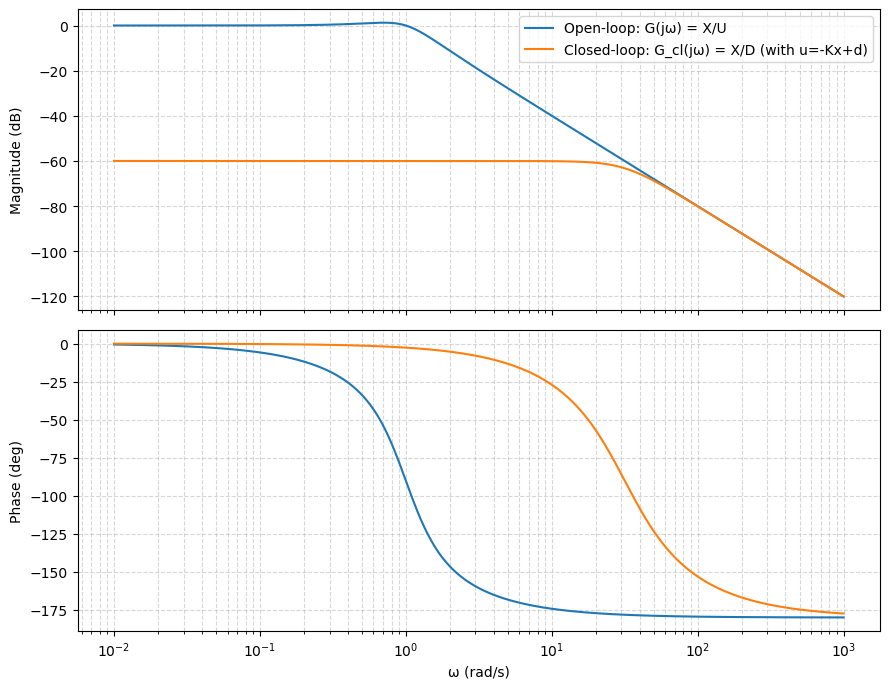

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

# ---- plant parameters (SI) ----
M = 1.0   # kg
C = 1.0   # N*s/m
K = 1.0   # N/m

# ---- continuous-time state-space (x, xdot) ----
A = np.array([[0.0,     1.0],
              [-K/M, -C/M]])
B = np.array([[0.0],
              [1.0/M]])

# ---- LQR weights: strongly penalize x ----
qx = 1e6     # <<< increase for even stronger x regulation
qv = 1e2     # penalty on xdot
r  = 1.0     # penalty on input effort

Q = np.diag([qx, qv])
R = np.array([[r]])

# ---- solve CARE and compute LQR gain ----
P = solve_continuous_are(A, B, Q, R)
K_lqr = np.linalg.solve(R, B.T @ P)   # 1x2
k1, k2 = float(K_lqr[0,0]), float(K_lqr[0,1])

print("LQR gain K_lqr = [k1 k2] =", K_lqr)
print("k1 =", k1, " (acts like extra stiffness)")
print("k2 =", k2, " (acts like extra damping)")

# ---- frequency grid ----
w = np.logspace(-2, 3, 2000)  # rad/s
s = 1j * w

# ---- open-loop and closed-loop disturbance->x transfer functions ----
G_open = 1.0 / (M*s**2 + C*s + K)
G_cl   = 1.0 / (M*s**2 + (C + k2)*s + (K + k1))  # from disturbance d to x

def bode(H):
    mag_db = 20*np.log10(np.abs(H))
    phase_deg = np.unwrap(np.angle(H)) * 180/np.pi
    return mag_db, phase_deg

mag_o, ph_o = bode(G_open)
mag_c, ph_c = bode(G_cl)

# ---- plot (open vs closed on same axes) ----
fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax[0].semilogx(w, mag_o, label="Open-loop: G(jω) = X/U")
ax[0].semilogx(w, mag_c, label="Closed-loop: G_cl(jω) = X/D (with u=-Kx+d)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].grid(True, which="both", ls="--", alpha=0.5)
ax[0].legend()

ax[1].semilogx(w, ph_o, label="Open-loop phase")
ax[1].semilogx(w, ph_c, label="Closed-loop phase")
ax[1].set_ylabel("Phase (deg)")
ax[1].set_xlabel("ω (rad/s)")
ax[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


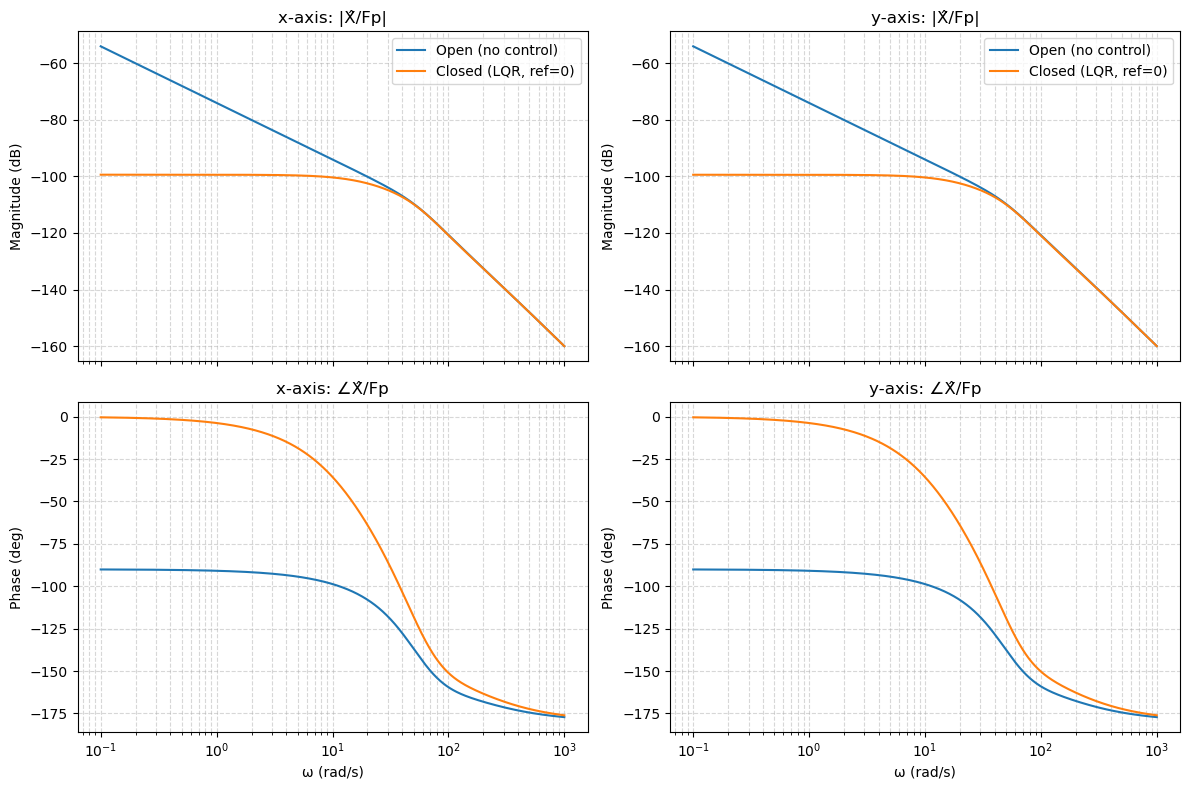

array([[ 7.25982007e+04, -1.00000000e+05, -1.28417444e+02,
        -1.88853860e+03,  6.60834909e-10, -7.06114723e-10,
         2.53003804e-13, -1.37893376e-11],
       [ 6.31320508e-10, -7.72540739e-10, -7.99837226e-13,
        -1.46245378e-11,  7.04792402e+04, -1.00000000e+05,
        -1.59123361e+02, -1.88546184e+03]])

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

# Parameters (SI)
mp = np.array([100.0, 100.0])          # attached TCP mass per axis (kg)
MR = np.array([120.0, 150.0])          # compliant/back mass per axis (kg)
Kstruct = np.array([1e6, 1e6])         # stiffness per axis (N/m)
zeta = 0.7                             # "well damped"
Cstruct = 2*zeta*np.sqrt(Kstruct*MR)   # damping per axis (N*s/m)
nu = np.array([5e3, 5e3])              # actuator viscous coupling (N*s/m) between masses

def axis_matrices(MR_i, C_i, K_i, mp_i, nu_i):
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [-K_i/MR_i, 0, -(C_i+nu_i)/MR_i,  nu_i/MR_i],
        [0, 0,  nu_i/mp_i,             -nu_i/mp_i],
    ], dtype=float)
    B = np.array([[0],[0],[1/MR_i],[-1/mp_i]], dtype=float)
    E = np.array([[0],[0],[0],[1/mp_i]], dtype=float)  # disturbance force on TCP mass
    Cy = np.array([[0,1,0,0]], dtype=float)            # output y = x_hat
    return A, B, E, Cy

# Build 2-axis (block diagonal) system
A_blocks, B_blocks, E_blocks, C_blocks = [], [], [], []
for i in range(2):
    A_i, B_i, E_i, C_i = axis_matrices(MR[i], Cstruct[i], Kstruct[i], mp[i], nu[i])
    A_blocks.append(A_i); B_blocks.append(B_i); E_blocks.append(E_i); C_blocks.append(C_i)

A = np.block([[A_blocks[0], np.zeros((4,4))],
              [np.zeros((4,4)), A_blocks[1]]])
B = np.block([[B_blocks[0], np.zeros((4,1))],
              [np.zeros((4,1)), B_blocks[1]]])  # 8x2 (u_x, u_y)
E = np.block([[E_blocks[0], np.zeros((4,1))],
              [np.zeros((4,1)), E_blocks[1]]])  # 8x2 (Fpx, Fpy)
Cout = np.block([[C_blocks[0], np.zeros((1,4))],
                 [np.zeros((1,4)), C_blocks[1]]]) # 2x8, outputs [xhat_x, xhat_y]

# LQR weighting: heavily penalize TCP deflection x_hat, tolerate base x
# State order per axis: [x, xhat, dx, dxhat]
Q_axis = np.diag([1e2, 1e8, 1.0, 1e4])
Q = np.block([[Q_axis, np.zeros((4,4))],
              [np.zeros((4,4)), Q_axis]])

# Input penalty (force). Keep moderate.
R = np.diag([1e-2, 1e-2])

# Solve CARE and compute K
P = solve_continuous_are(A, B, Q, R)
K_lqr = np.linalg.solve(R, B.T @ P)  # 2x8

# Frequency response from disturbance Fp -> xhat (open and closed)
w = np.logspace(-1, 3, 1500)  # rad/s
s = 1j*w

def freq_resp(A, E, C, s):
    n = A.shape[0]
    m = E.shape[1]
    p = C.shape[0]
    H = np.zeros((p, m, len(s)), dtype=complex)
    I = np.eye(n)
    for k, sk in enumerate(s):
        X = np.linalg.solve(sk*I - A, E)  # n x m
        H[:,:,k] = C @ X                  # p x m
    return H

A_cl = A - B @ K_lqr

H_open = freq_resp(A, E, Cout, s)   # 2x2xN, diagonal dominant
H_cl   = freq_resp(A_cl, E, Cout, s)

def mag_phase(H):
    mag_db = 20*np.log10(np.maximum(np.abs(H), 1e-18))
    ph_deg = np.unwrap(np.angle(H), axis=2) * 180/np.pi
    return mag_db, ph_deg

mag_o, ph_o = mag_phase(H_open)
mag_c, ph_c = mag_phase(H_cl)

# Plot for each axis: Fp_i -> xhat_i (diagonal terms)
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col')
axes_names = ["x-axis", "y-axis"]
for i in range(2):
    axs[0,i].semilogx(w, mag_o[i,i,:], label="Open (no control)")
    axs[0,i].semilogx(w, mag_c[i,i,:], label="Closed (LQR, ref=0)")
    axs[0,i].set_title(f"{axes_names[i]}: |X̂/Fp|")
    axs[0,i].set_ylabel("Magnitude (dB)")
    axs[0,i].grid(True, which="both", ls="--", alpha=0.5)
    axs[0,i].legend()

    axs[1,i].semilogx(w, ph_o[i,i,:], label="Open")
    axs[1,i].semilogx(w, ph_c[i,i,:], label="Closed")
    axs[1,i].set_title(f"{axes_names[i]}: ∠X̂/Fp")
    axs[1,i].set_ylabel("Phase (deg)")
    axs[1,i].set_xlabel("ω (rad/s)")
    axs[1,i].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

K_lqr

